# Representational similarity analysis

Visualizes `results/rsa.npz` from `scripts/run_analyses.py`. RDMs are 1 − Pearson r between unit timecourses (condition means, from frame2 onward). Corrections vs the legacy notebooks: trial averaging, strict-lower-triangle second-order correlation, and active-unit masking — see `illusion_rnn/analysis.py`.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
R = np.load(ROOT / "results" / "rsa.npz", allow_pickle=False)
META = json.loads((ROOT / "results" / "meta.json").read_text())
VARIANTS = META["variants"]
DIRS = ["left", "middle", "right"]
print("active units:", META["n_active_units"], "of 2048")
print("accuracies:", META["accuracy"])

active units: 1047 of 2048
accuracies: {'standard': 0.967, 'outline': 0.1, 'basic': 0.967}


## 1. Unit-by-unit RDMs per direction

The same most-active units (shared across variants) — standard on top, outline below. Similar structure across the three directions within a variant means direction is encoded by trajectory geometry more than by which units co-fire.

Text(0.5, 0.98, 'Unit RDMs (30 most-active shared units)')

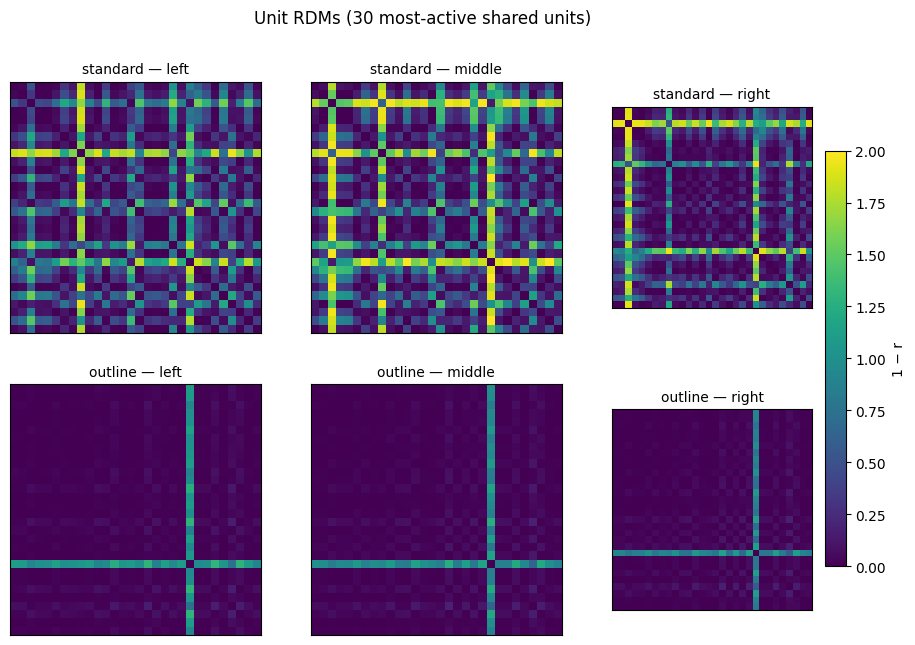

In [2]:
show_variants = [v for v in ("standard", "outline") if v in VARIANTS]
fig, axes = plt.subplots(len(show_variants), 3,
                         figsize=(11, 3.6 * len(show_variants)),
                         squeeze=False)
for row, variant in enumerate(show_variants):
    rdms = R[f"{variant}_unit_rdms"]
    for col in range(3):
        ax = axes[row][col]
        im = ax.imshow(rdms[col], vmin=0, vmax=2, cmap="viridis")
        ax.set_title(f"{variant} — {DIRS[col]}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
fig.colorbar(im, ax=axes[:, -1], shrink=0.75, label="1 − r")
fig.suptitle(f"Unit RDMs ({rdms.shape[1]} most-active shared units)")

## 2. Second-order RDMs: do directions share similarity structure?

Each cell compares two directions' full-network RDMs (active units only).

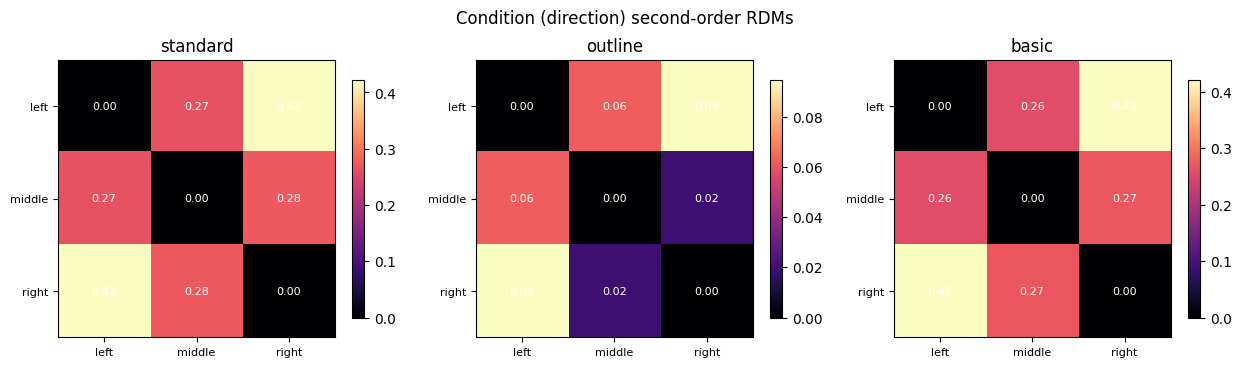

In [3]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.2 * len(VARIANTS), 3.6))
for ax, variant in zip(axes, VARIANTS):
    matrix = R[f"{variant}_condition_rdm"]
    im = ax.imshow(matrix, vmin=0, cmap="magma")
    ax.set_xticks(range(3))
    ax.set_xticklabels(DIRS, fontsize=8)
    ax.set_yticks(range(3))
    ax.set_yticklabels(DIRS, fontsize=8)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center",
                    va="center", color="w", fontsize=8)
    ax.set_title(f"{variant}")
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("Condition (direction) second-order RDMs")
fig.tight_layout()

## 3. Cross-variant RSA: is outline TAM represented like standard TAM?

Second-order dissimilarity between all 9 (variant × direction) full-network RDMs. Block structure by variant (gridlines every 3) answers the headline question directly.

mean within-standard block: 0.214
mean standard-outline block: 0.82
mean standard-basic block: 0.213


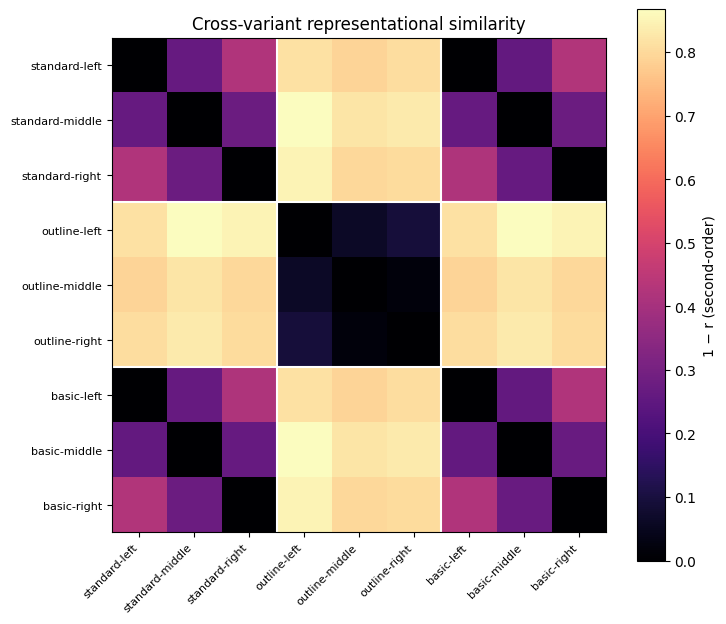

In [4]:
keys = [str(k) for k in R["cross_keys"]]
matrix = R["cross_rdm"]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(matrix, vmin=0, cmap="magma")
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(keys)))
ax.set_yticklabels(keys, fontsize=8)
for cut in (2.5, 5.5):
    ax.axhline(cut, color="w", lw=1.5)
    ax.axvline(cut, color="w", lw=1.5)
fig.colorbar(im, label="1 − r (second-order)")
ax.set_title("Cross-variant representational similarity")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "rsa_cross_variant.png", dpi=150,
            bbox_inches="tight")
block = lambda a, b: float(np.mean(matrix[a * 3:(a + 1) * 3, b * 3:(b + 1) * 3]))
print("mean within-standard block:", round(block(0, 0), 3))
print("mean standard-outline block:", round(block(0, 1), 3))
print("mean standard-basic block:", round(block(0, 2), 3))

## Reading the matrix

If the standard–basic off-diagonal block is nearly as similar as the within-variant blocks while the standard–outline block stands apart, the network carries a shared TAM representation that outline stimuli fail to engage — the representational counterpart of the behavioral generalization pattern (standard/basic ≈ 0.97, outline ≈ 0.10). If instead outline sits inside the same representational family, the failure is downstream of the representation (a readout problem). The printed block means above give the quantitative answer for this run.